# Chapter 48 — Uncertainty Propagation
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 48 — Uncertainty Propagation.

When Lord Kelvin propagated the uncertainty in his cooling model to date the Earth, the arithmetic was impeccable and the answer was wrong by nearly a hundredfold — a standing reminder that propagation tells you how uncertain a result is *given that the model is right*, never whether the model itself is right. This notebook stays on the honest side of that line: it takes a model we trust and asks how the uncertainties of its inputs combine into the uncertainty of its output.

Propagating uncertainty through a measurement model means converting the uncertainties of the input quantities into the uncertainty of the output quantity. The **GUM analytical method** does this by linearizing the measurement function: each input uncertainty *u(xᵢ)* is multiplied by the corresponding **sensitivity coefficient** *cᵢ = ∂f/∂xᵢ*, and the weighted contributions are combined in quadrature. For measurement functions that are nearly linear over the range of interest, the analytical method is accurate and efficient.

When the measurement function is significantly nonlinear — or when the input distributions are not well-described by standard forms — the **Monte Carlo method** (Supplement 1 to the GUM) provides a more rigorous alternative. Random samples are drawn from each input distribution, the measurement function is evaluated for each sample set, and the distribution of the output is computed from the ensemble. The standard uncertainty is simply the standard deviation of the output samples; confidence intervals can be read directly from the empirical distribution without assuming normality.

The quarter-bridge strain formula *ε = 4 V_out / (V_ex · GF)* is nearly linear in *V_out* but slightly nonlinear in *GF* and *V_ex* because they appear in the denominator. For the uncertainties typical in strain measurement, the GUM and Monte Carlo methods agree to within a fraction of a percent. This notebook demonstrates both approaches on the same measurement to show the agreement and illustrate when the more rigorous Monte Carlo method is warranted.

**This notebook demonstrates:**
1. Monte Carlo uncertainty propagation (N = 100,000 trials) for a quarter-bridge strain measurement, checked against the GUM analytical result.

In [1]:
# !pip install numpy matplotlib scipy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures are written next to the book's Chapter 48 source so the build picks them up.
OUT_DIR = Path("../src/media/ch48")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — GUM Analytical vs. Monte Carlo Propagation

The simulation below draws N = 100,000 samples from the distributions of *GF*, *V_ex*, and *V_out*, evaluates *ε = 4 V_out / (V_ex · GF)* for each sample set, and plots the resulting output distribution. The histogram should approximate a normal distribution if the inputs are normal and the function is reasonably linear — and for this measurement, it does.

The Monte Carlo result (standard deviation of the 100,000 output values) is compared directly against the GUM analytical result (quadrature sum of *cᵢ · uᵢ* terms). For the quarter-bridge formula at these uncertainty levels, the two methods agree to within a fraction of a percent — confirming that the linearization implicit in the GUM is valid here. If the measurement function were more strongly nonlinear, or if one input had a highly asymmetric distribution, the Monte Carlo method would diverge from the GUM and provide a more accurate picture of the actual output uncertainty.

The input standard uncertainties used here (0.5 % on *GF*, 10 mV on the 5 V excitation, and a small ADC-noise term on the bridge output) are illustrative *k* = 1 values chosen to exercise the method — they are not the specific budget behind the chapter's worked example in Eq. 48.5, so the combined uncertainty reported below is a demonstration figure rather than a reproduction of that example.

The figure shows the output distribution with its mean, the ±2σ bounds (the expanded uncertainty at *k* = 2), and the fitted normal curve. The near-perfect fit between the histogram and the normal curve is itself evidence that the GUM approximation is justified in this case.

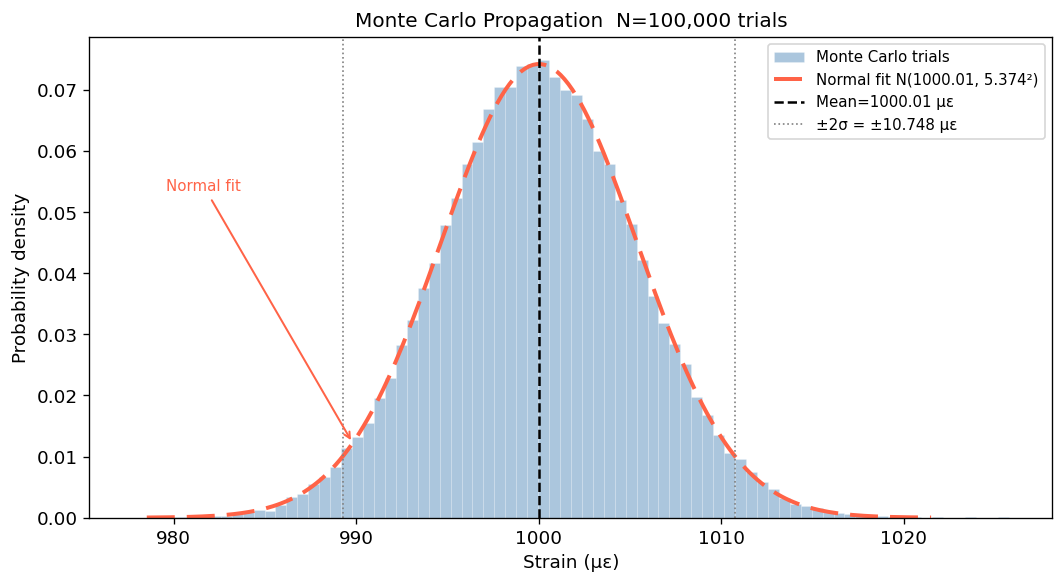

Monte Carlo: u_c = 5.3738 με  (N=100,000)
GUM method:  u_c = 5.3853 με
Agreement: 0.21%


In [2]:
# Monte Carlo uncertainty propagation for a quarter-bridge strain measurement.
# Model (Chapter 48, Eq. 48.3):  epsilon = 4 * Vout / (Vex * GF) * 1e6   [microstrain]

# --- Nominal values and standard (k = 1) uncertainties ---
N_TRIALS      = 100_000   # number of Monte Carlo trials
STRAIN_NOM_UE = 1000.0    # nominal indicated strain, microstrain
RANDOM_SEED   = 0         # fix the RNG so the saved figure is reproducible

GF_NOM     = 2.07         # gage factor, nominal
GF_REL_STD = 0.005        # gage-factor standard uncertainty, fractional (0.5%)
VEX_NOM_V  = 5.00         # bridge excitation voltage, V
VEX_STD_V  = 0.010        # excitation standard uncertainty, V (10 mV)
VOUT_STD_V = 1e-7         # bridge-output (ADC) noise standard uncertainty, V

# Bridge output that produces STRAIN_NOM_UE at the nominal gage factor and excitation.
VOUT_NOM_V = VEX_NOM_V * GF_NOM * (STRAIN_NOM_UE * 1e-6) / 4.0


def quarter_bridge_strain(vout, vex, gf):
    """Indicated strain in microstrain from a quarter bridge (Eq. 48.3)."""
    return 4.0 * vout / (vex * gf) * 1e6


# Draw each input from its distribution (draw order fixed for reproducibility),
# then evaluate the model once per trial.
np.random.seed(RANDOM_SEED)
GF_mc   = np.random.normal(GF_NOM,     GF_NOM * GF_REL_STD, N_TRIALS)
Vex_mc  = np.random.normal(VEX_NOM_V,  VEX_STD_V,           N_TRIALS)
Vout_mc = np.random.normal(VOUT_NOM_V, VOUT_STD_V,          N_TRIALS)
eps_mc  = quarter_bridge_strain(Vout_mc, Vex_mc, GF_mc)

mu    = eps_mc.mean()
sigma = eps_mc.std()

fig, ax = plt.subplots(figsize=(9, 5))
# The bars are held light and the fitted curve is dashed and labeled in place,
# so the fit stays visible against the histogram in black-and-white print.
ax.hist(eps_mc, bins=80, color='steelblue', alpha=0.45, edgecolor='white',
        linewidth=0.3, density=True, label='Monte Carlo trials')
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
ax.plot(x, norm.pdf(x, mu, sigma), color='tomato', lw=2.4, linestyle=(0, (7, 3)),
        label=f'Normal fit N({mu:.2f}, {sigma:.3f}²)')
x_lab = mu - 1.9 * sigma
ax.annotate('Normal fit', xy=(x_lab, norm.pdf(x_lab, mu, sigma)),
            xytext=(mu - 3.8 * sigma, norm.pdf(mu, mu, sigma) * 0.72),
            fontsize=9, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2))
ax.axvline(mu, color='black', lw=1.5, linestyle='--', label=f'Mean={mu:.2f} με')
ax.axvline(mu - 2 * sigma, color='gray', lw=1, linestyle=':')
ax.axvline(mu + 2 * sigma, color='gray', lw=1, linestyle=':', label=f'±2σ = ±{2 * sigma:.3f} με')
ax.set_xlabel('Strain (με)')
ax.set_ylabel('Probability density')
ax.set_title(f'Monte Carlo Propagation  N={N_TRIALS:,} trials')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig48_nb1_uncertainty_monte_carlo.png', bbox_inches='tight', dpi=300)
plt.show()

# GUM analytical result: fractional uncertainties combine in quadrature (Eq. 48.4),
# scaled by the nominal strain to give microstrain.
u_GUM = STRAIN_NOM_UE * np.sqrt(
    GF_REL_STD**2
    + (VEX_STD_V / VEX_NOM_V)**2
    + (VOUT_STD_V / VOUT_NOM_V)**2
)
print(f"Monte Carlo: u_c = {sigma:.4f} με  (N={N_TRIALS:,})")
print(f"GUM method:  u_c = {u_GUM:.4f} με")
print(f"Agreement: {abs(sigma - u_GUM) / sigma * 100:.2f}%")

---
## Where to take this next

This notebook covers only the simplest case in the chapter — a three-input multiplicative model where GUM and Monte Carlo agree almost exactly. The chapter develops several harder cases that are worth building here:

1. **Reproduce the rosette stress budget (Table 48.1).** Implement the principal-stress formula (Eq. 48.7) for a rectangular 0°/45°/90° rosette, compute the five sensitivity coefficients by central difference (Eq. 48.6), and assemble the *cᵢ · uᵢ* budget. Confirm that Young's modulus *E*, not the strain channels, dominates the combined uncertainty.
2. **Find a case where Monte Carlo and GUM disagree.** Push the maximum-principal-stress calculation toward a near-equibiaxial state, where the square root in Eq. 48.7 sits close to zero. The output distribution becomes skewed and bounded below, the symmetric ±2σ interval no longer matches the 2.5th/97.5th percentiles, and only Monte Carlo captures the true coverage.
3. **Add correlated inputs (Eq. 48.8).** Split each rosette channel's uncertainty into a shared-calibration component and an independent component, then show how positive correlation among the three channels changes the combined stress uncertainty relative to the naive root-sum-of-squares — sometimes larger, sometimes smaller, depending on how the sensitivity coefficients add.